# GPT-2 구축 프로젝트 — 실험 파이프라인

7조 | 정예경 · 정연주 · 김도원

GitHub: https://github.com/ygjung03/nlp2026

## 0. 환경 설정

In [1]:
!git clone https://github.com/ygjung03/nlp2026.git
%cd nlp2026
!pip install einops

Cloning into 'nlp2026'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 121 (delta 40), reused 108 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 31.19 MiB | 9.32 MiB/s, done.
Resolving deltas: 100% (40/40), done.
Updating files: 100% (62/62), done.
/content/nlp2026


## 1. Paraphrase Detection

> **Note:** 단일 T4 GPU 환경에서 전체 학습 데이터(141,506건)로 10 epoch 학습이 약 17시간 소요되어, 시간 제약상 학습 데이터를 20,000건으로 축소하여 실험을 진행하였습니다. 코드 자체는 전체 데이터셋으로 정상 실행 가능하도록 구현되어 있습니다.

In [12]:
!sed -i "s/torch.load(args.filepath)/torch.load(args.filepath, weights_only=False)/g" paraphrase_detection.py
!sed -i "s/torch.load(filepath)/torch.load(filepath, weights_only=False)/g" paraphrase_detection.py
!python paraphrase_detection.py --use_gpu --epochs 5 --batch_size 32

Loaded 19999 train examples from data/quora-train.csv
Loaded 40429 train examples from data/quora-dev.csv
Loading weights: 100% 148/148 [00:00<00:00, 5727.02it/s]
train-0: 100% 625/625 [06:19<00:00,  1.65it/s]
eval: 100% 1264/1264 [04:04<00:00,  5.16it/s]
save the model to 5-1e-05-paraphrase.pt
Epoch 0: train loss :: 0.669, dev acc :: 0.762
train-1: 100% 625/625 [06:24<00:00,  1.62it/s]
eval: 100% 1264/1264 [04:07<00:00,  5.11it/s]
save the model to 5-1e-05-paraphrase.pt
Epoch 1: train loss :: 0.478, dev acc :: 0.796
train-2: 100% 625/625 [06:23<00:00,  1.63it/s]
eval: 100% 1264/1264 [04:06<00:00,  5.13it/s]
save the model to 5-1e-05-paraphrase.pt
Epoch 2: train loss :: 0.416, dev acc :: 0.813
train-3: 100% 625/625 [06:22<00:00,  1.63it/s]
eval: 100% 1264/1264 [04:06<00:00,  5.14it/s]
save the model to 5-1e-05-paraphrase.pt
Epoch 3: train loss :: 0.370, dev acc :: 0.822
train-4: 100% 625/625 [06:24<00:00,  1.63it/s]
eval: 100% 1264/1264 [04:04<00:00,  5.17it/s]
save the model to 5-1e-0

## 2. Sonnet Generation — 실험 1: 조기 종료 전략 초기 비교

3가지 조기 종료 전략(val_loss, perplexity, TTR)을 구현하고 baseline과 비교한다.

In [ ]:
!python sonnet_generation.py --exp_name baseline --stopping_method none --use_gpu

Loading weights: 100% 148/148 [00:00<00:00, 11962.71it/s]
train-0: 100% 15/15 [00:05<00:00,  2.63it/s]
Epoch 0: train loss :: 4.739, train perplexity :: 114.362.
Epoch 0: val loss :: 4.492.
Generating several output sonnets...
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;se lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
Her quarrel again deeped into mine hearts;
Our kiss from your the Heaven of bend
And squeezed anxious throttle but never friend The passion all doing Until now 5 perfect Lovers mired unconscious Remot one enjoying and distracted
********************************  People ought not to grow to love mortals growing after Or laughing about (brought no tale) ?  Even have the love (lover) set
So you allow these voices, Touch not my actual love Because d n he brought still more NO
Sadness resisted any of the great aspiration But waking ot

In [ ]:
!python sonnet_generation.py --exp_name val_loss --stopping_method val_loss --use_gpu

Loading weights: 100% 148/148 [00:00<00:00, 5258.07it/s]
train-0: 100% 15/15 [00:05<00:00,  2.51it/s]
Epoch 0: train loss :: 4.739, train perplexity :: 114.362.
Epoch 0: val loss :: 4.492.
Generating several output sonnets...
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;se lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
Her quarrel again deeped into mine hearts;
Our kiss from your the Heaven of bend
And squeezed anxious throttle but never friend The passion all doing Until now 5 perfect Lovers mired unconscious Remot one enjoying and distracted
********************************  People ought not to grow to love mortals growing after Or laughing about (brought no tale) ?  Even have the love (lover) set
So you allow these voices, Touch not my actual love Because d n he brought still more NO
Sadness resisted any of the great aspiration But waking oth

In [ ]:
!python sonnet_generation.py --exp_name ppl --stopping_method perplexity --use_gpu

Loading weights: 100% 148/148 [00:00<00:00, 25489.96it/s]
train-0: 100% 15/15 [00:05<00:00,  2.59it/s]
Epoch 0: train loss :: 4.739, train perplexity :: 114.362.
Epoch 0: val loss :: 4.492.
Generating several output sonnets...
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;se lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
Her quarrel again deeped into mine hearts;
Our kiss from your the Heaven of bend
And squeezed anxious throttle but never friend The passion all doing Until now 5 perfect Lovers mired unconscious Remot one enjoying and distracted
********************************  People ought not to grow to love mortals growing after Or laughing about (brought no tale) ?  Even have the love (lover) set
So you allow these voices, Touch not my actual love Because d n he brought still more NO
Sadness resisted any of the great aspiration But waking ot

In [ ]:
!python sonnet_generation.py --exp_name ttr --stopping_method diversity --use_gpu

Loading weights: 100% 148/148 [00:00<00:00, 5298.23it/s]
train-0: 100% 15/15 [00:06<00:00,  2.48it/s]
Epoch 0: train loss :: 4.739, train perplexity :: 114.362.
Epoch 0: val loss :: 4.492.
Generating several output sonnets...
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;se lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
Her quarrel again deeped into mine hearts;
Our kiss from your the Heaven of bend
And squeezed anxious throttle but never friend The passion all doing Until now 5 perfect Lovers mired unconscious Remot one enjoying and distracted
********************************  People ought not to grow to love mortals growing after Or laughing about (brought no tale) ?  Even have the love (lover) set
So you allow these voices, Touch not my actual love Because d n he brought still more NO
Sadness resisted any of the great aspiration But waking oth

## 3. Sonnet Generation — 실험 2: Perplexity 임계값 재조정

초기 target=5.0이 실제 perplexity 범위(82→46)와 괴리가 있어, target=60으로 재설정하여 재실험한다.

In [ ]:
!python sonnet_generation.py --exp_name ppl2 --stopping_method perplexity --target_perplexity 60 --use_gpu

Loading weights: 100% 148/148 [00:00<00:00, 5156.22it/s]
train-0: 100% 15/15 [00:05<00:00,  2.60it/s]
Epoch 0: train loss :: 4.739, train perplexity :: 114.362.
Epoch 0: val loss :: 4.492.
Generating several output sonnets...
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;se lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
Her quarrel again deeped into mine hearts;
Our kiss from your the Heaven of bend
And squeezed anxious throttle but never friend The passion all doing Until now 5 perfect Lovers mired unconscious Remot one enjoying and distracted
********************************  People ought not to grow to love mortals growing after Or laughing about (brought no tale) ?  Even have the love (lover) set
So you allow these voices, Touch not my actual love Because d n he brought still more NO
Sadness resisted any of the great aspiration But waking oth

## 4. Sonnet Generation — 실험 3: 디코딩 전략 비교

동일한 baseline 체크포인트에서 디코딩 파라미터(temperature, top_p, top_k)를 변경하며 생성 품질을 비교한다. top-k 샘플링은 직접 구현하였다.

In [ ]:
!python decode_compare.py --use_gpu

Loading checkpoint from 9_baseline_10-1e-05-sonnet.pt...
Loading weights: 100% 148/148 [00:00<00:00, 6143.13it/s]

Generating with: greedy (temperature=0.1, top_p=1.0)
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
But now, when I see her,
I see her in her beauty,
And I see her in her beauty's beauty's beauty,
And I see her in her beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty's beauty

Poor soul, the center of my sinful earth,
Pressed with these rebel powers that thee array,
Why dost thou pine within and suffer dearth,
And yet thou dost not find me,
Thy love, thy

## 5. Sonnet Generation — 실험 4: LoRA 적용 및 학습률 탐색

LoRA(rank=4)를 직접 구현하여 GPT-2의 Q, V projection에 적용하고, 학습률을 1e-5, 1e-4, 3e-4로 탐색한다. 전체 117M 파라미터 중 약 147K개(0.13%)만을 학습 대상으로 설정하였다.

In [ ]:
!git pull
!python sonnet_generation.py --exp_name lora --stopping_method none --use_lora --lora_rank 4 --use_gpu

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.12 KiB | 287.00 KiB/s, done.
From https://github.com/ygjung03/nlp2026
   aef4c1c..22f0dda  main       -> origin/main
Updating aef4c1c..22f0dda
Fast-forward
 sonnet_generation.py | 45 +++++++++++++++++++++++++++++++++++++++++----
 1 file changed, 41 insertions(+), 4 deletions(-)
Loading weights: 100% 148/148 [00:00<00:00, 6853.51it/s]
train-0: 100% 15/15 [00:04<00:00,  3.06it/s]
Epoch 0: train loss :: 5.217, train perplexity :: 184.370.
Epoch 0: val loss :: 5.134.
Generating several output sonnets...
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;se lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake; to realize what Lou Preci

In [ ]:
!python sonnet_generation.py --exp_name lora_highlr --stopping_method none --use_lora --lora_rank 4 --lr 3e-4 --use_gpu

Loading weights: 100% 148/148 [00:00<00:00, 8821.83it/s]
train-0: 100% 15/15 [00:05<00:00,  2.93it/s]
Epoch 0: train loss :: 5.208, train perplexity :: 182.742.
Epoch 0: val loss :: 5.104.
Generating several output sonnets...
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;se lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake; to fight, scoff, understand….
For comfort, cake, Rain's punishment tonight is too harsh…..I will scream…..- Diary writing, I shall let you find peace
Peace, feeling; Mother Lately summer is crashing over me, tomorrow I must revyle […] holding down on January Everytime sex gone up, come home, Now Maøpcor. From us there. we shall bring back once free from the slag that shouldn't be here This sword holds firmly to Wen Cheng
Daddy, Mo Is under strain Master Teacher, Missouri, law enforcement Ignore me and miss Mo Vil in Crime hidden d

In [ ]:
!python sonnet_generation.py --exp_name lora_midlr --stopping_method none --use_lora --lora_rank 4 --lr 1e-4 --use_gpu

Loading weights: 100% 148/148 [00:00<00:00, 5501.17it/s]
train-0: 100% 15/15 [00:05<00:00,  2.95it/s]
Epoch 0: train loss :: 5.215, train perplexity :: 184.091.
Epoch 0: val loss :: 5.130.
Generating several output sonnets...
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;se lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake; to realize what bond shou didn't need thee
Not until Helena conceived Helen wroth about her lover.
These fingers not once hold her hands.
Fall Be Fallme Grete Sueeureeng anyone heartlesses
Unless into loathsome sadoes another desperation or avarice's secrets only go
Over his scary passions ghosts drunk in future love on it Might blow
His dubious books tell't what he sees at last, see what whit before fallen lovers pines Choose with wanted forces
Encreasing fofulhy, pervading vexation racked with love Wife so shell that Phineas dre

## 6. 전체 실험 결과 시각화

4가지 실험의 chrF 및 TTR을 동적으로 계산하고 그래프로 비교한다.

 Exp 1: Early Stopping Initial Comparison
baseline                  chrF=27.459  TTR=48.00%  unique=613
val_loss                  chrF=27.459  TTR=48.00%  unique=613
ppl(5.0)                  chrF=27.459  TTR=48.00%  unique=613
ttr                       chrF=23.213  TTR=54.27%  unique=553


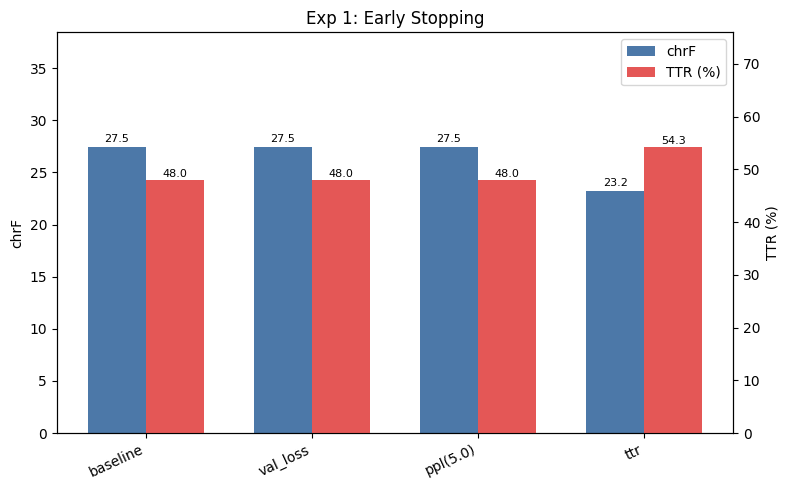


 Exp 2: Perplexity Threshold Adjustment
baseline                  chrF=27.459  TTR=48.00%  unique=613
ppl2(60)                  chrF=26.299  TTR=51.68%  unique=630


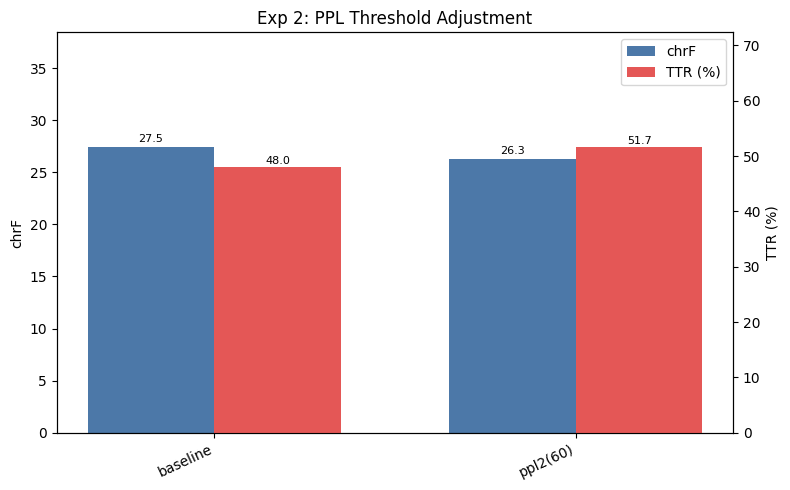


 Exp 3: Decoding Strategy Comparison
greedy(0.1)               chrF=16.076  TTR=12.60%  unique=199
conservative(0.7)         chrF=24.996  TTR=25.06%  unique=340
baseline(1.2)             chrF=27.459  TTR=48.00%  unique=613
creative(1.5)             chrF=27.029  TTR=71.21%  unique=997
top_k_50                  chrF=26.898  TTR=30.91%  unique=421
top_k_10                  chrF=25.322  TTR=22.62%  unique=300


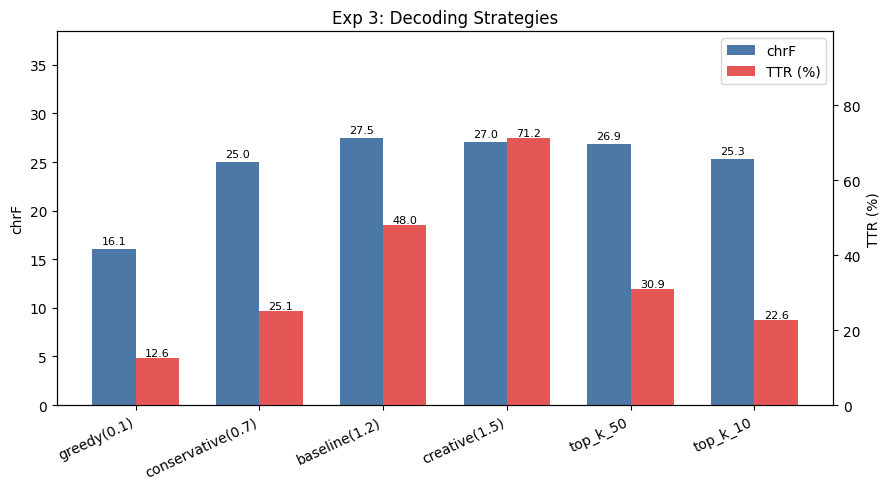


 Exp 4: LoRA Learning Rate Search
Full FT(1e-5)             chrF=27.459  TTR=48.00%  unique=613
LoRA(1e-5)                chrF=25.800  TTR=62.80%  unique=839
LoRA(1e-4)                chrF=23.619  TTR=61.30%  unique=716
LoRA(3e-4)                chrF=22.766  TTR=54.87%  unique=575


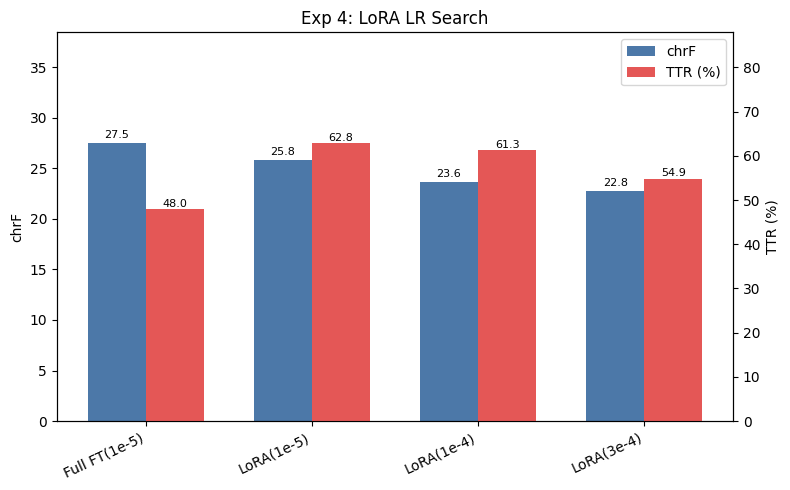

In [17]:
# ===== 동적 평가 + 그래프 (compare_experiments.py 로직 그대로) =====
import matplotlib.pyplot as plt
import numpy as np
from evaluation import test_sonnet
from datasets import SonnetsDataset

GOLD_PATH = 'data/TRUE_sonnets_held_out_dev.txt'

def evaluate(pred_path):
    chrf = test_sonnet(pred_path, GOLD_PATH)
    texts = [x[1] for x in SonnetsDataset(pred_path)]
    words = []
    for t in texts:
        words.extend(''.join(c if c.isalnum() else ' ' for c in t).lower().split())
    ttr = len(set(words)) / len(words) if words else 0
    unique = len(set(words))
    return chrf, ttr * 100, unique

def run_and_plot(title, experiments):
    names, chrfs, ttrs, uniques = [], [], [], []
    for name, path in experiments.items():
        try:
            c, t, u = evaluate(path)
            names.append(name)
            chrfs.append(c)
            ttrs.append(t)
            uniques.append(u)
            print(f'{name:<25} chrF={c:.3f}  TTR={t:.2f}%  unique={u}')
        except Exception as e:
            print(f'{name:<25} ERROR: {e}')

    if not names:
        return

    fig, ax1 = plt.subplots(figsize=(max(8, len(names)*1.5), 5))
    x = np.arange(len(names)); w = 0.35
    ax1.bar(x - w/2, chrfs, w, label='chrF', color='#4C78A8')
    ax1.set_ylabel('chrF'); ax1.set_ylim(0, max(chrfs) * 1.4)
    ax2 = ax1.twinx()
    ax2.bar(x + w/2, ttrs, w, label='TTR (%)', color='#E45756')
    ax2.set_ylabel('TTR (%)'); ax2.set_ylim(0, max(ttrs) * 1.4)
    ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=25, ha='right')
    ax1.set_title(title)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    for i, v in enumerate(chrfs):
        ax1.text(i - w/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
    for i, v in enumerate(ttrs):
        ax2.text(i + w/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
    plt.tight_layout(); plt.show()

# ===== 실험별 실행 =====
print('='*60)
print(' Exp 1: Early Stopping Initial Comparison')
print('='*60)
run_and_plot('Exp 1: Early Stopping', {
    'baseline': 'predictions/generated_sonnets_baseline.txt',
    'val_loss': 'predictions/generated_sonnets_val_loss.txt',
    'ppl(5.0)': 'predictions/generated_sonnets_ppl.txt',
    'ttr': 'predictions/generated_sonnets_ttr.txt',
})

print('\n' + '='*60)
print(' Exp 2: Perplexity Threshold Adjustment')
print('='*60)
run_and_plot('Exp 2: PPL Threshold Adjustment', {
    'baseline': 'predictions/generated_sonnets_baseline.txt',
    'ppl2(60)': 'predictions/generated_sonnets_ppl2.txt',
})

print('\n' + '='*60)
print(' Exp 3: Decoding Strategy Comparison')
print('='*60)
run_and_plot('Exp 3: Decoding Strategies', {
    'greedy(0.1)': 'predictions/generated_sonnets_decode_greedy.txt',
    'conservative(0.7)': 'predictions/generated_sonnets_decode_conservative.txt',
    'baseline(1.2)': 'predictions/generated_sonnets_decode_baseline.txt',
    'creative(1.5)': 'predictions/generated_sonnets_decode_creative.txt',
    'top_k_50': 'predictions/generated_sonnets_decode_top_k_50.txt',
    'top_k_10': 'predictions/generated_sonnets_decode_top_k_10.txt',
})

print('\n' + '='*60)
print(' Exp 4: LoRA Learning Rate Search')
print('='*60)
run_and_plot('Exp 4: LoRA LR Search', {
    'Full FT(1e-5)': 'predictions/generated_sonnets_baseline.txt',
    'LoRA(1e-5)': 'predictions/generated_sonnets_lora.txt',
    'LoRA(1e-4)': 'predictions/generated_sonnets_lora_midlr.txt',
    'LoRA(3e-4)': 'predictions/generated_sonnets_lora_highlr.txt',
})